W notesie przedstawiono szczegółową analizę czynników wpływających na przedwczesne kończenie nauki przez studentów. Badanie oparto na zbiorze danych zatytułowanym „Predict Students Dropout, Academic Success”, pochodzącym z platformy Kaggle, którego autorem jest użytkownik thedevastator. Zestaw ten zawiera szeroki zakres atrybutów, które pozwalają na identyfikację zjawisk determinujących rezygnację ze studiów lub osiągnięcie sukcesu akademickiego.

Zmienne można podzielić na cztery główne kategorie tematyczne:
1. Dane demograficzne i społeczno-ekonomiczne
•	Stan cywilny oraz pochodzenie: Zmienne określające stan cywilny (Marital status), narodowość (Nacionality) oraz status studenta zagranicznego (International).
•	Sytuacja rodzinna: Szczegółowe dane dotyczące wykształcenia oraz profilu zawodowego rodziców (Mother's/Father's qualification oraz Mother's/Father's occupation), pozwalające na ocenę wpływu kapitału kulturowego i ekonomicznego gospodarstwa domowego.
•	Czynniki migracyjne i adaptacyjne: Informacja o tym, czy student musiał zmienić miejsce zamieszkania w celu podjęcia nauki (Displaced).
2. Profil rekrutacyjny i kontekst instytucjonalny
•	Informacje o rekrutacji: Tryb aplikacji (Application mode), priorytet wybranego kierunku (Application order) oraz dotychczasowe formalne wykształcenie (Previous qualification).
•	Organizacja toku studiów: Wybrany kierunek (Course) oraz tryb odbywania zajęć – dzienny lub wieczorowy (Daytime/evening attendance).
•	Profil indywidualny: Wiek w momencie podejmowania studiów (Age at enrollment), płeć (Gender) oraz obecność specjalnych potrzeb edukacyjnych (Educational special needs).
3. Status finansowy studenta
•	Zobowiązania i wsparcie: Wskaźniki określające, czy student posiada zadłużenie wobec uczelni (Debtor), czy regularnie opłaca czesne (Tuition fees up to date) oraz czy przyznano mu wsparcie materialne w postaci stypendium (Scholarship holder).
4. Osiągnięcia akademickie (w rozbiciu na 1. i 2. semestr)
Dla każdego z dwóch pierwszych semestrów gromadzone są precyzyjne wskaźniki efektywności naukowej:
•	Liczba punktów/przedmiotów przepisywanych z innych kierunków (credited).
•	Liczba przedmiotów, na które student został zapisany (enrolled).
•	Liczba podejść do egzaminów i zaliczeń (evaluations).
•	Liczba faktycznie zaliczonych przedmiotów (approved).
•	Średnia uzyskanych ocen (grade).
•	Liczba przedmiotów porzuconych bez próby podejścia do weryfikacji wiedzy (without evaluations).
5. Wskaźniki makroekonomiczne
Kontekst zewnętrzny w momencie rejestracji danych uzupełniają trzy wskaźniki gospodarcze kraju: stopa bezrobocia (Unemployment rate), stopa inflacji (Inflation rate) oraz dynamika PKB (GDP).
Zmienna docelowa (Target)
Zmienna objaśniana Target jest zmienną kategoryczną o charakterze klasyfikacyjnym, przyjmującą trzy stany:
	1.	Dropout – student przedwcześnie przerwał naukę (skreślenie lub rezygnacja).
	2.	Enrolled – student kontynuuje naukę (pozostaje w systemie).
	3.	Graduate – student pomyślnie ukończył cykl kształcenia i uzyskał dyplom.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier


import warnings
warnings.filterwarnings('ignore', message='.*[Hh]ue.*', category=FutureWarning)


data = pd.read_csv("./dataset.csv")
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [11]:
data.isnull().sum()/len(data)*100

Marital status                                    0.0
Application mode                                  0.0
Application order                                 0.0
Course                                            0.0
Daytime/evening attendance                        0.0
Previous qualification                            0.0
Nacionality                                       0.0
Mother's qualification                            0.0
Father's qualification                            0.0
Mother's occupation                               0.0
Father's occupation                               0.0
Displaced                                         0.0
Educational special needs                         0.0
Debtor                                            0.0
Tuition fees up to date                           0.0
Gender                                            0.0
Scholarship holder                                0.0
Age at enrollment                                 0.0
International               

### W zbiorze danych nie ma pustych wartości

In [12]:
print(data["Target"].unique())

<StringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str


### Kolumna target przyjmuje wartości Dropout, Graduate, Enrolled, więc można je zamienić na 0, 1, 2.

In [13]:
data['Target'] = data['Target'].map({
    'Dropout':0,
    'Enrolled':1,
    'Graduate':2
})

print(data["Target"].unique())

[0 2 1]


### Usuwamy dane nie mające korelacji z target

In [14]:
data.corr()['Target']

Marital status                                   -0.089804
Application mode                                 -0.212025
Application order                                 0.089791
Course                                            0.007841
Daytime/evening attendance                        0.075107
Previous qualification                           -0.091365
Nacionality                                      -0.004740
Mother's qualification                           -0.038346
Father's qualification                            0.000329
Mother's occupation                               0.048424
Father's occupation                               0.051702
Displaced                                         0.113986
Educational special needs                        -0.007353
Debtor                                           -0.240999
Tuition fees up to date                           0.409827
Gender                                           -0.229270
Scholarship holder                                0.2975

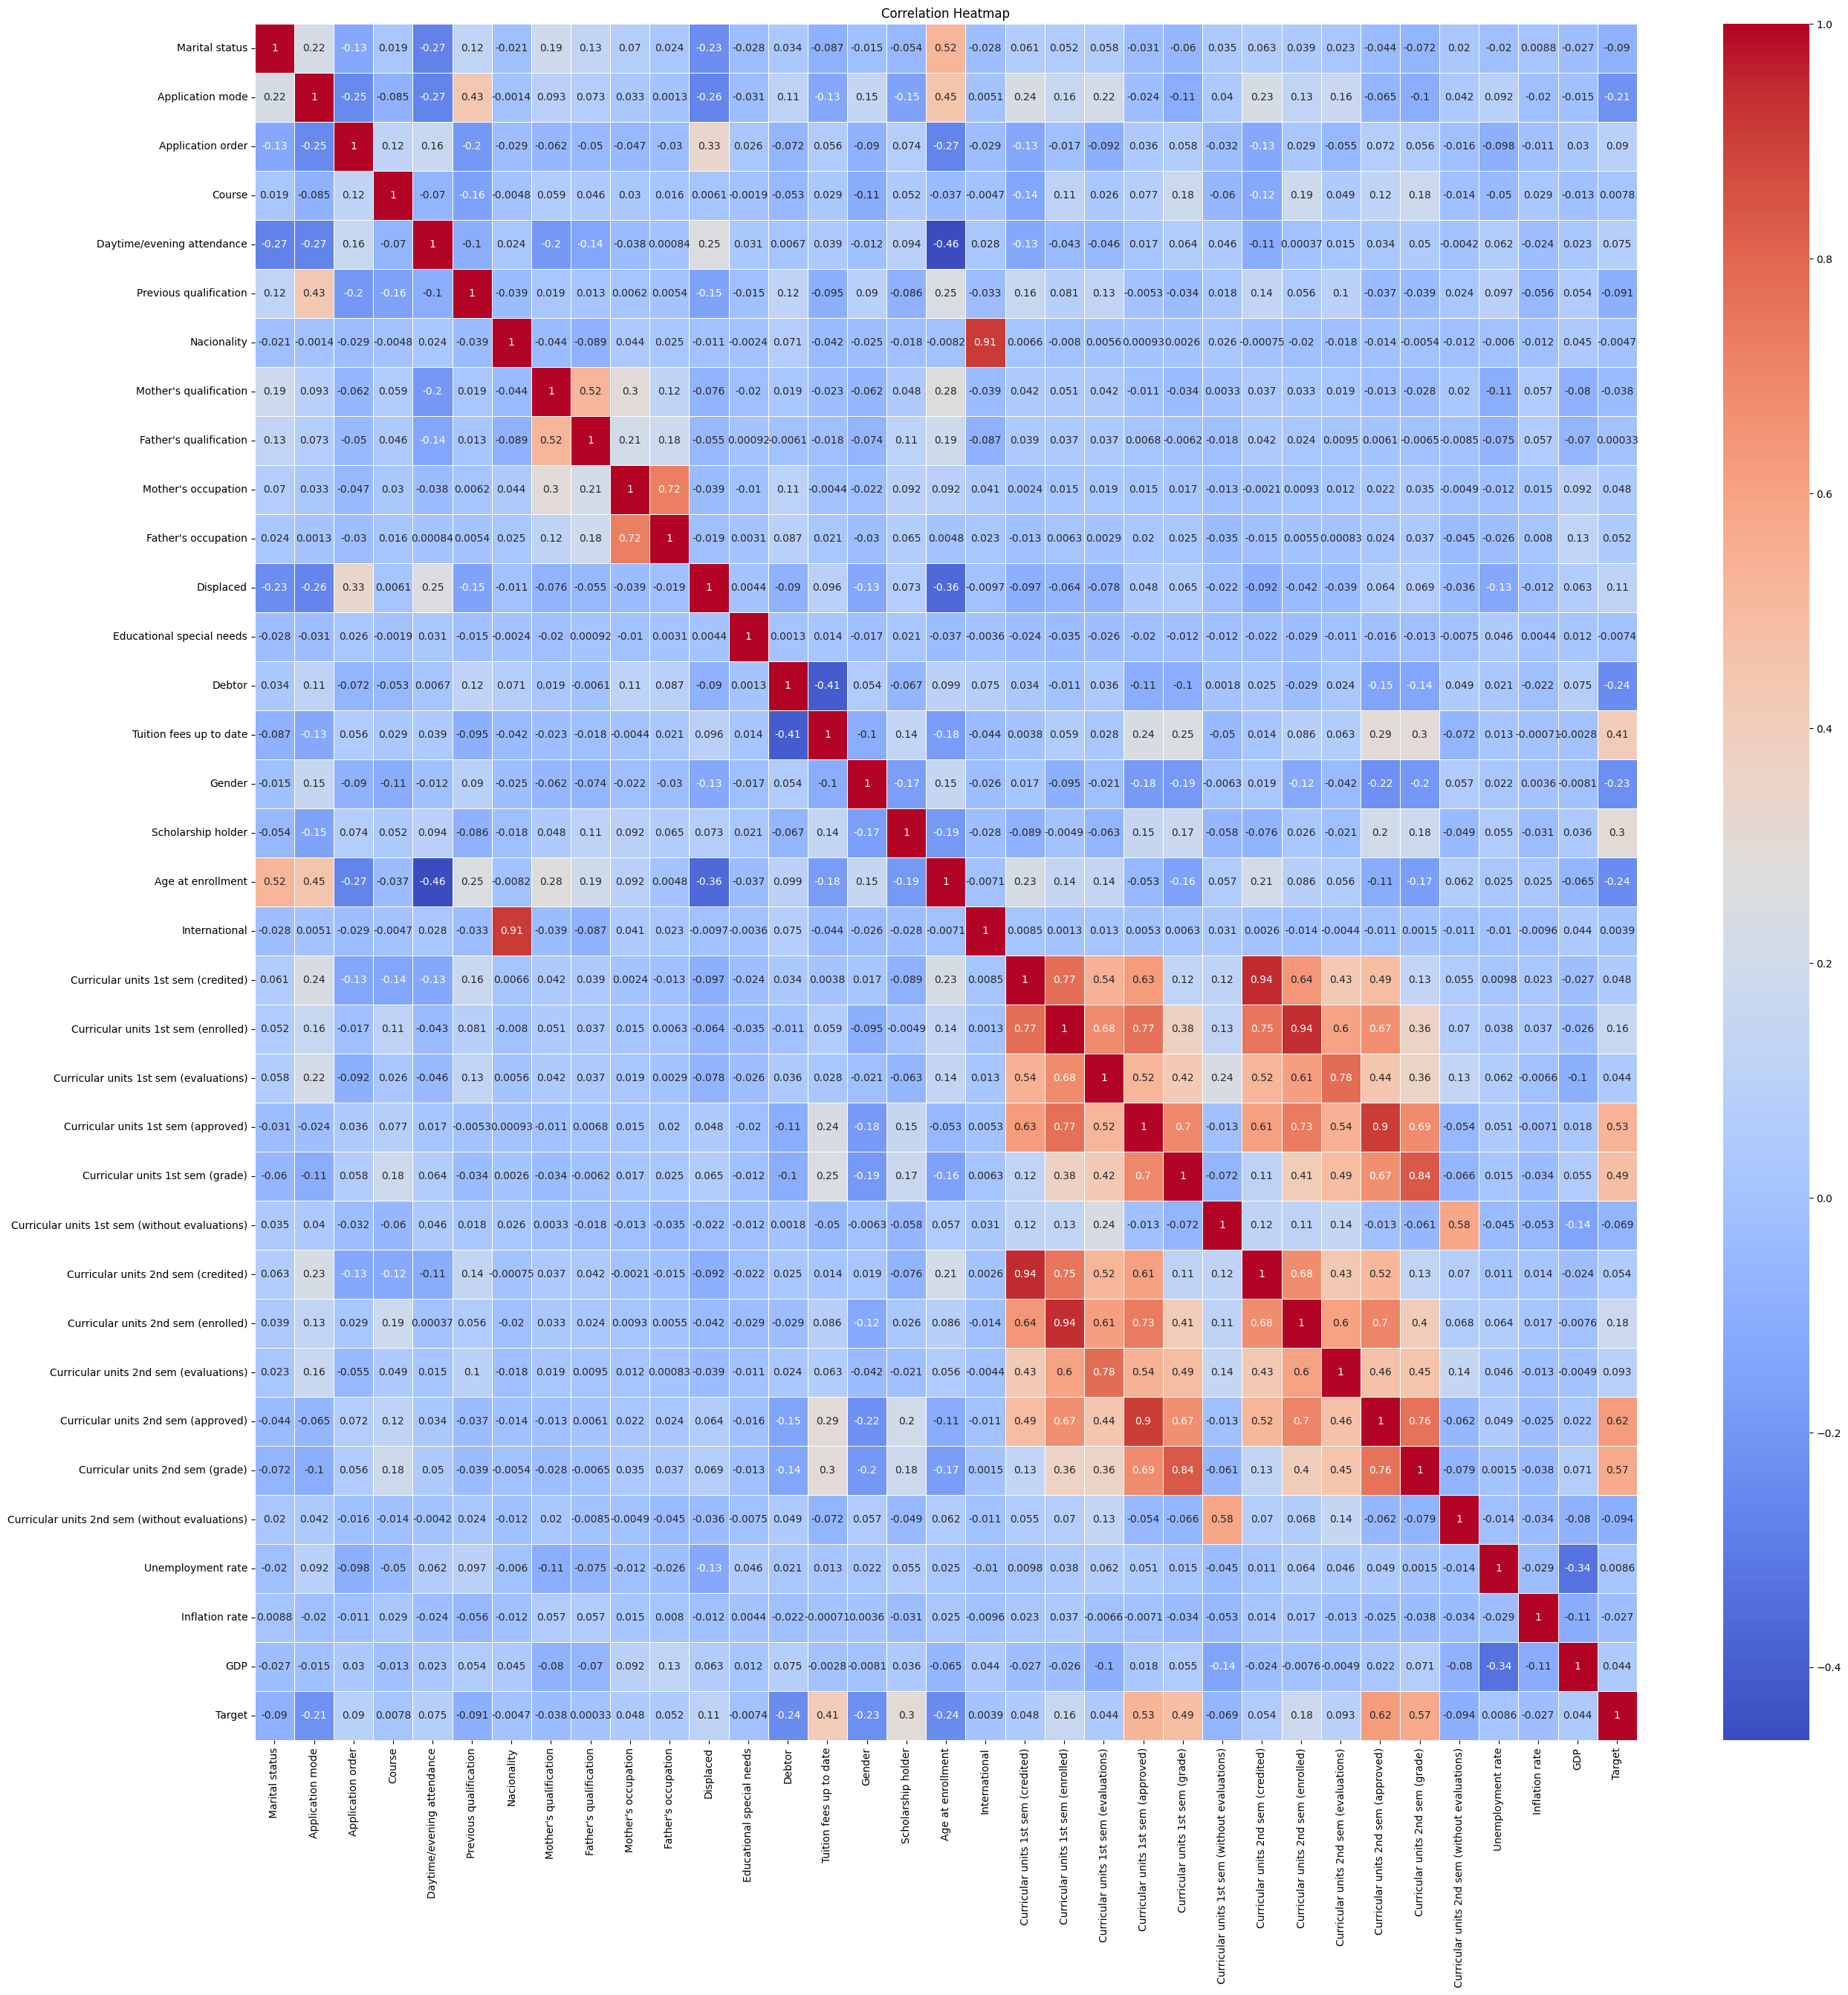

In [15]:
plt.figure(figsize=(30, 30))
sns.heatmap(data.corr() , annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Sprawdźmy jaka wartość |korelacja| < wartość sprawdza się najlepiej

Top 10 najmniej skorelowanych z 'Target':


,abs_corr
Father's qualification,0.000329
International,0.003934
Nacionality,0.004740
Educational special needs,0.007353
Course,0.007841
Unemployment rate,0.008627
Inflation rate,0.026874
Mother's qualification,0.038346
GDP,0.044135
Curricular units 1st sem (evaluations),0.044362



Kolumny z |korelacja| < 0.04:


,abs_corr
Father's qualification,0.000329
International,0.003934
Nacionality,0.004740
Educational special needs,0.007353
Course,0.007841
Unemployment rate,0.008627
Inflation rate,0.026874
Mother's qualification,0.038346


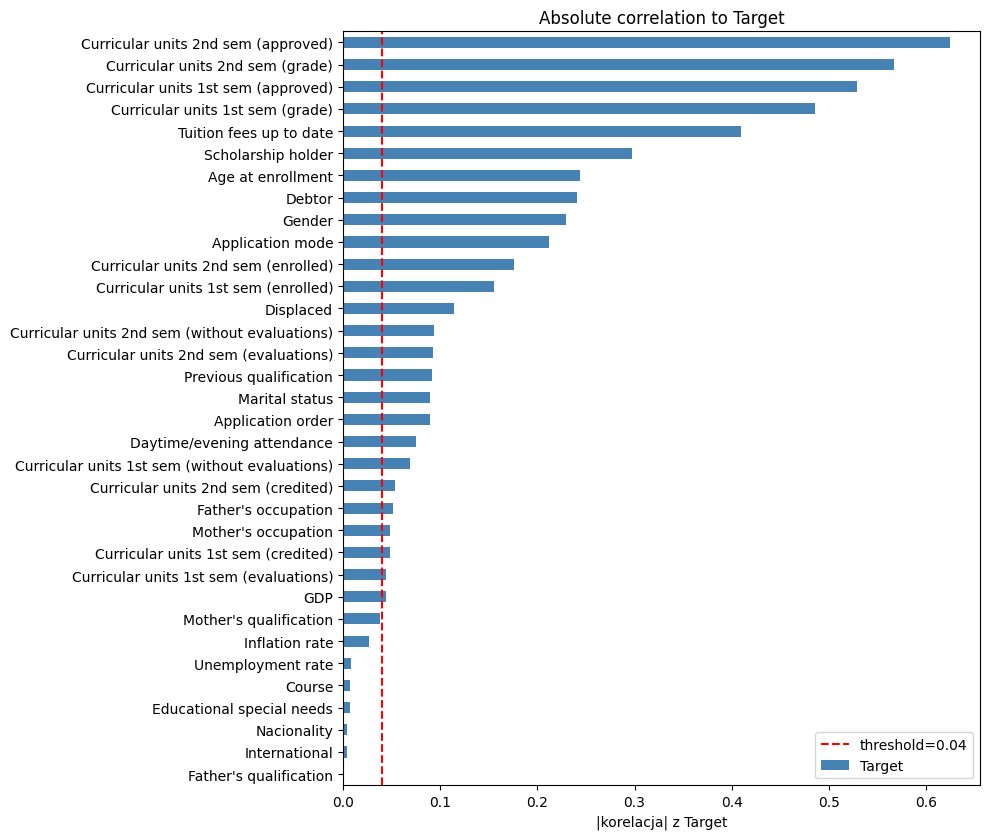

In [20]:
def top_drop_candidates(df, target='Target', threshold=0.04, top_n=10, plot=True):


    num = df.select_dtypes(include=[np.number]).copy()
    if target not in num.columns:
        raise ValueError(f"Kolumna docelowa '{target}' nie istnieje lub nie jest numeryczna.")

    corrs = num.corr()[target].drop(labels=[target]).abs().sort_values()
    top_n_low = corrs.head(top_n)
    top1 = corrs.head(1)
    below_thr = corrs[corrs < threshold]

    print(f"Top {top_n} najmniej skorelowanych z '{target}':")
    display(top_n_low.to_frame(name='abs_corr'))

    print(f'\nKolumny z |korelacja| < {threshold}:')
    if below_thr.empty:
        print('Brak kolumn poniżej progu.')
    else:
        display(below_thr.to_frame(name='abs_corr'))

    if plot:
        plt.figure(figsize=(10, max(4, len(corrs)*0.25)))
        corrs.plot(kind='barh', color='steelblue')
        plt.axvline(threshold, color='red', linestyle='--', label=f'threshold={threshold}')
        plt.xlabel('|korelacja| z ' + target)
        plt.title('Absolute correlation to ' + target)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {'sorted_abs_corr': corrs, 'top_n_low': top_n_low, 'top1': top1, 'below_threshold': below_thr}


res = top_drop_candidates(data, target='Target', threshold=0.04, top_n=10, plot=True)

In [21]:
# Zapis kolumn poniżej progu do listy
drop_cols = res['below_threshold'].index.tolist()
print(f"Liczba kolumn poniżej progu: {len(drop_cols)}")
drop_cols

Liczba kolumn poniżej progu: 8


["Father's qualification",
 'International',
 'Nacionality',
 'Educational special needs',
 'Course',
 'Unemployment rate',
 'Inflation rate',
 "Mother's qualification"]

### Dla dokładności modelu możemy usunąć dane mające mniej niż 0.04 korelacji z kolumną target.

In [19]:
new_data = data.copy()
new_data = new_data.drop(columns=drop_cols)
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Daytime/evening attendance                      4424 non-null   int64  
 4   Previous qualification                          4424 non-null   int64  
 5   Mother's occupation                             4424 non-null   int64  
 6   Father's occupation                             4424 non-null   int64  
 7   Displaced                                       4424 non-null   int64  
 8   Debtor                                          4424 non-null   int64  
 9   Tuition fees up to date                         4424

#EDA
Ilość wartości dropouts, enrolled i graduates

In [22]:
new_data['Target'].value_counts()

Target
2    2209
0    1421
1     794
Name: count, dtype: int64

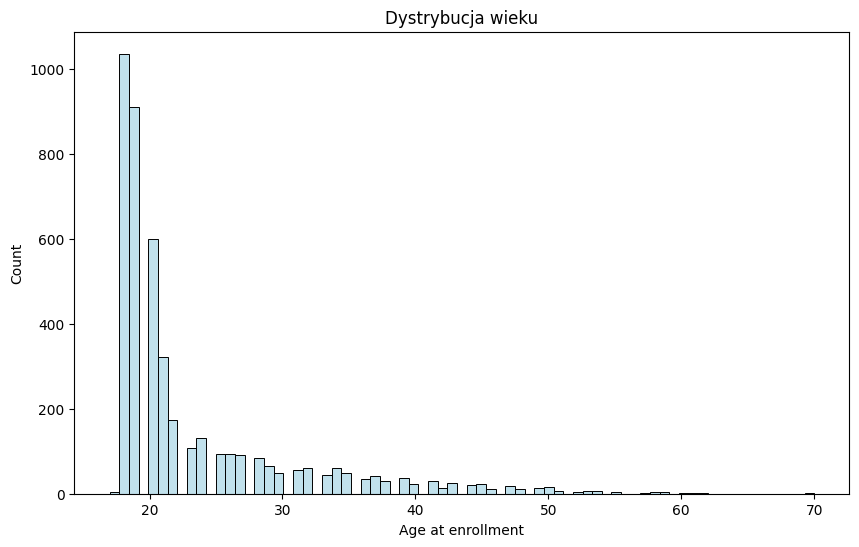

In [24]:
plt.figure(figsize=(10,6))
sns.histplot(new_data['Age at enrollment'], color='lightblue', kde=False)
plt.xlabel('Age at enrollment')
plt.title('Dystrybucja wieku')
plt.show()

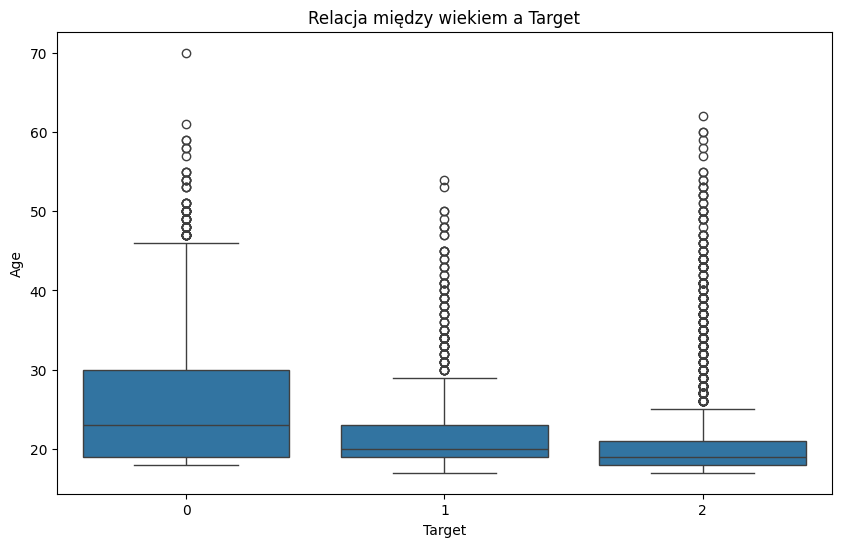

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='Age at enrollment', data=new_data)
plt.xlabel('Target')
plt.ylabel('Age')
plt.title('Relacja między wiekiem a Target')
plt.show()

In [26]:
X = new_data.drop('Target', axis=1)
y = new_data['Target']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=67)

## Modele do analizy danych 


Do klasyfikacji tego zbioru używa się najczęściej 4 modeli:

- XGBoost 
- Random Forest
- Regresja Logistyczna 
- LightGBM

Każdy z tych modeli ma swoje wady i zalety.

XGBoost jest świetny do danych tabelarycznych, działając na zasadzie sekwencyjnego budowania drzew decyzyjnych, gdzie każde kolejne drzewo poprawia błędy swoich poprzedników.

Radzi sobie dobrze z nieliniowymi relacjami i nie wymaga skalowania danych.

Wadą jest to, że wymaga tuningu hiperparametrów oraz łatwo go przeuczyć.

Random Forest to model typu Ensemble oparty na tzw. baggingu – tworzy setki niezależnych drzew decyzyjnych i podejmuje decyzję na zasadzie większościowego głosowania. Jest niezwykle stabilny, odporny na outliery (wartości odstające, np. nietypowo starych studentów) i praktycznie nie wymaga skalowania danych. Wadą jest to, że może mieć problem z idealnym dopasowaniem, jeśli granice decyzyjne są bardzo subtelne.

Regresja Logistyczna może też być dobrym wyborem. Ponieważ nasz Target ma 3 klasy (Dropout, Enrolled, Graduate), regresja logistyczna w wersji wielomianowej (Multinomial) posłuży jako idealny model bazowy (baseline). Wadą jest to, że zakłada liniowość, więc słabo wychwyci skomplikowane zależności między zmiennymi makroekonomicznymi a wynikami studenta.

LightGBM to alternatywa dla XGBoost stworzona przez Microsoft, która optymalizuje proces budowania drzew poprzez pionowy wzrost (leaf-wise), a nie poziomy (level-wise).
Jest niesamowicie szybki i zużywa mało pamięci. Dobrze radzi sobie z cechami kategorycznymi (jak Course, Mother's occupation, Marital status), które w tym zbiorze są zakodowane jako liczby całkowite – LightGBM potrafi je przetwarzać bez konieczności stosowania pamięciożernego One-Hot Encodingu. Wadą jest to, że przy mniejszej liczbie danych może wykazywać tendencję do overfittingu, ale przy ponad 4000 rekordów w tym zbiorze powinien poradzić sobie idealnie.


W tym projekcie skupimy się na Random Forest i XGBoost



Accuracy:  0.7616
Precision: 0.7186
Recall:    0.7059
F1-score:  0.7108


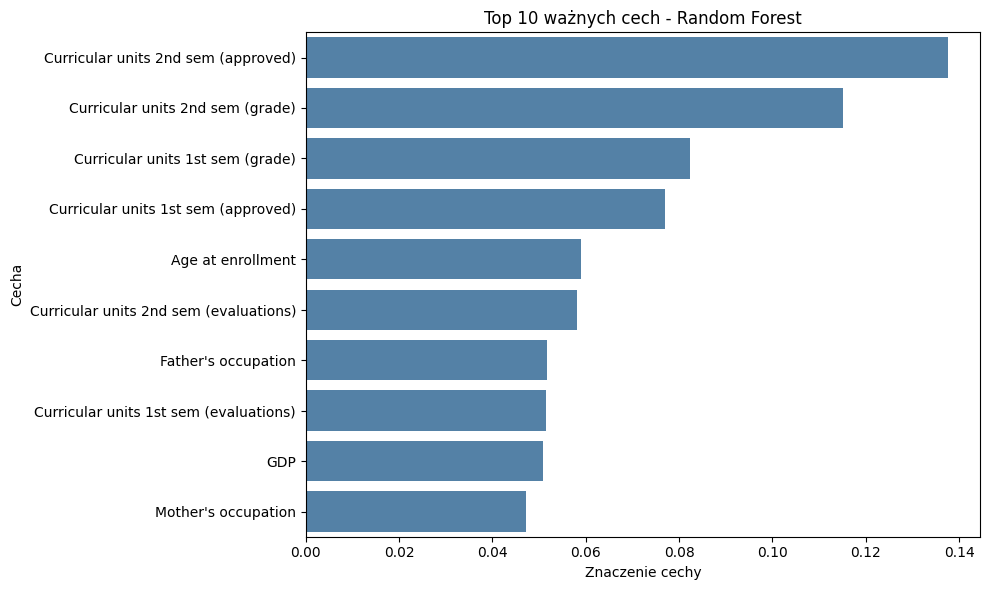

In [51]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, color="steelblue")
plt.title("Top 10 ważnych cech - Random Forest")
plt.xlabel("Znaczenie cechy")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

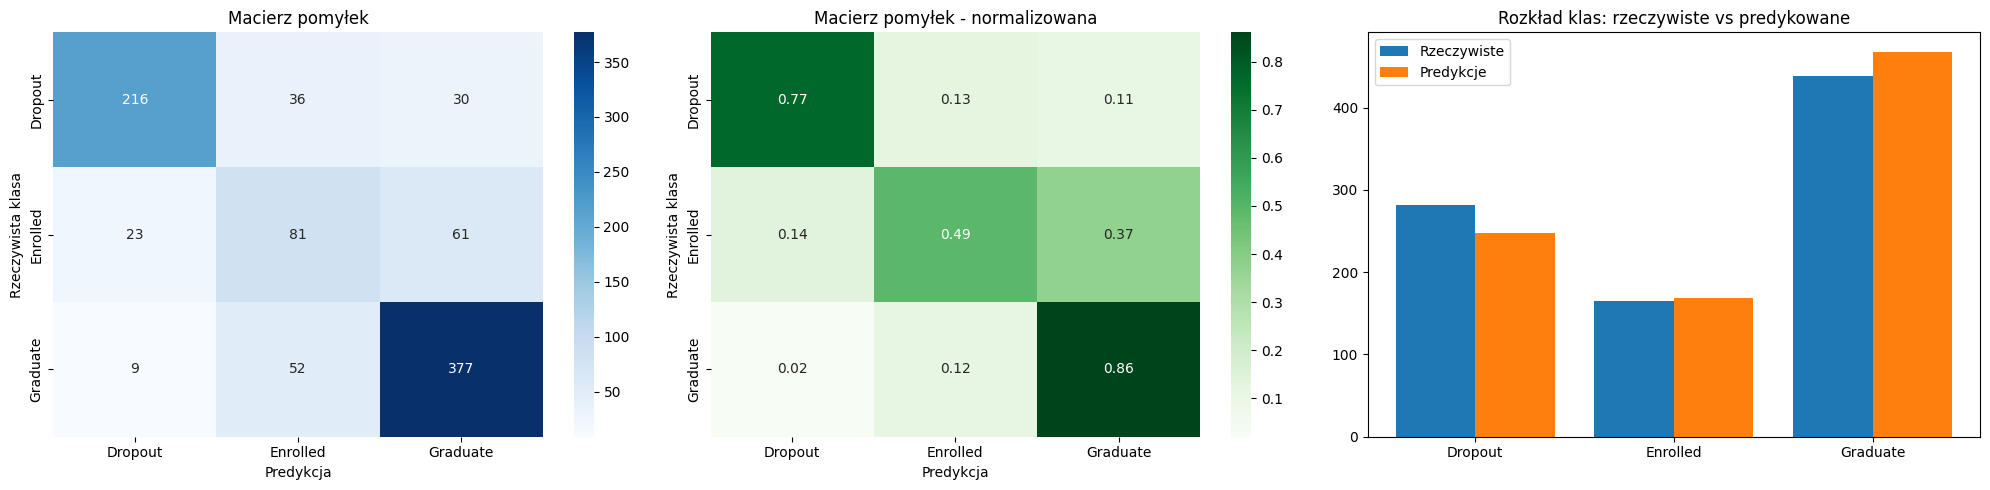

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["Dropout", "Enrolled", "Graduate"]

cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Macierz pomyłek")
axes[0].set_xlabel("Predykcja")
axes[0].set_ylabel("Rzeczywista klasa")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Macierz pomyłek - normalizowana")
axes[1].set_xlabel("Predykcja")
axes[1].set_ylabel("Rzeczywista klasa")

actual_counts = y_test.value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

x = range(len(labels))
axes[2].bar([i - 0.2 for i in x], actual_counts.values, width=0.4, label="Rzeczywiste")
axes[2].bar([i + 0.2 for i in x], pred_counts.reindex(actual_counts.index, fill_value=0).values,
            width=0.4, label="Predykcje")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(labels)
axes[2].set_title("Rozkład klas: rzeczywiste vs predykowane")
axes[2].legend()

plt.tight_layout()
plt.show()

XGBoost Accuracy:  0.7887
XGBoost Precision: 0.7511
XGBoost Recall:    0.7065
XGBoost F1-score:  0.7182


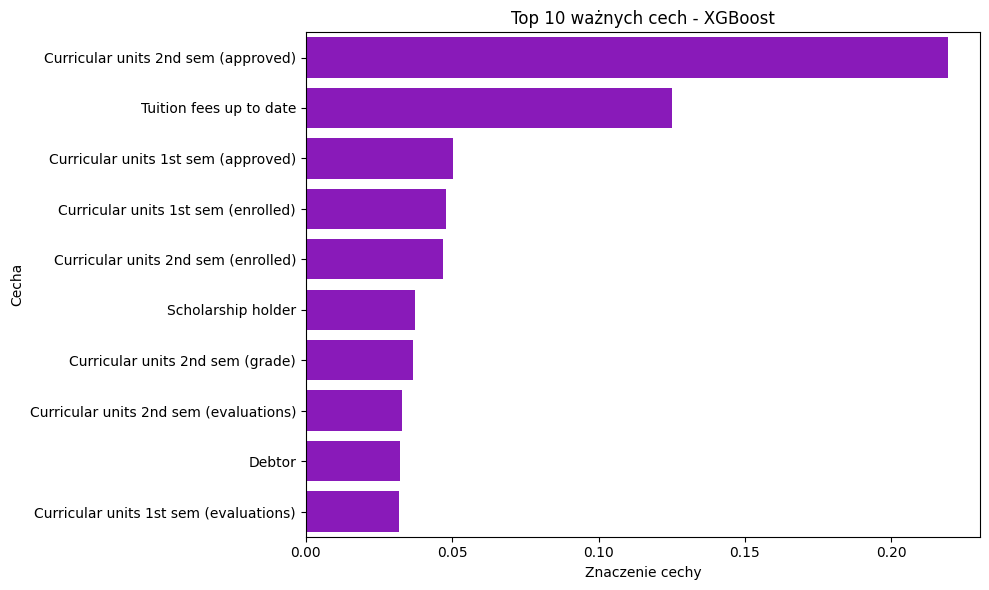

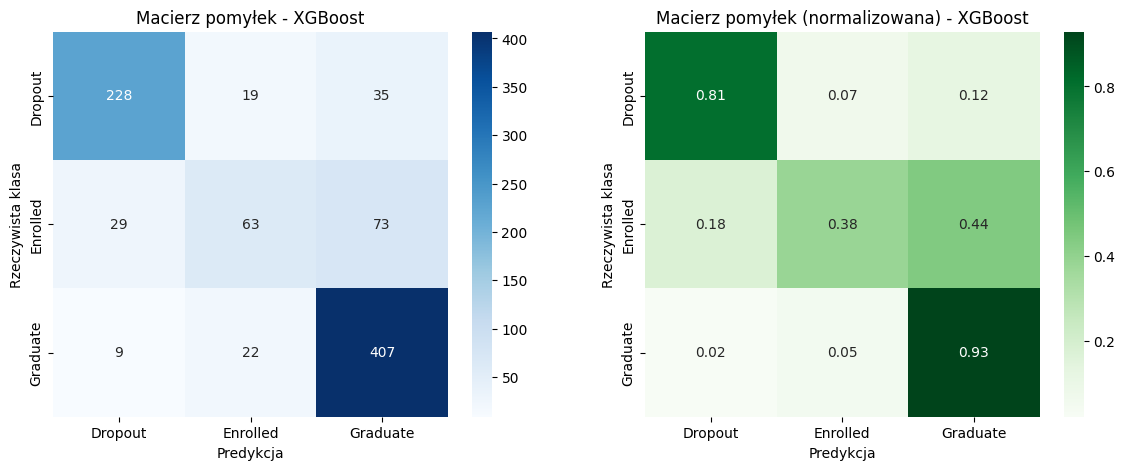

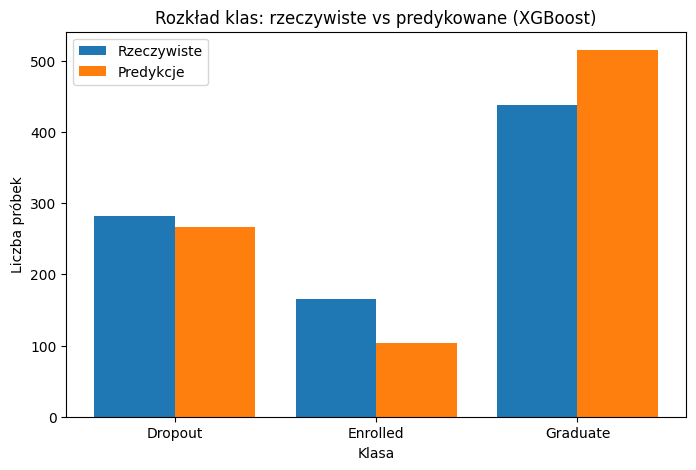

In [52]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred, average="macro")
xgb_recall = recall_score(y_test, xgb_y_pred, average="macro")
xgb_f1 = f1_score(y_test, xgb_y_pred, average="macro")

print(f"XGBoost Accuracy:  {xgb_accuracy:.4f}")
print(f"XGBoost Precision: {xgb_precision:.4f}")
print(f"XGBoost Recall:    {xgb_recall:.4f}")
print(f"XGBoost F1-score:  {xgb_f1:.4f}")

xgb_feature_importances = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=xgb_feature_importances.head(10).values,
    y=xgb_feature_importances.head(10).index,
    color="darkviolet"
)
plt.title("Top 10 ważnych cech - XGBoost")
plt.xlabel("Znaczenie cechy")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()

cm_xgb = confusion_matrix(y_test, xgb_y_pred)
cm_xgb_norm = confusion_matrix(y_test, xgb_y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)
axes[0].set_title("Macierz pomyłek - XGBoost")
axes[0].set_xlabel("Predykcja")
axes[0].set_ylabel("Rzeczywista klasa")

sns.heatmap(
    cm_xgb_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)
axes[1].set_title("Macierz pomyłek (normalizowana) - XGBoost")
axes[1].set_xlabel("Predykcja")
axes[1].set_ylabel("Rzeczywista klasa")
actual_counts_xgb = y_test.value_counts().sort_index()
pred_counts_xgb = pd.Series(xgb_y_pred).value_counts().sort_index()

plt.figure(figsize=(8, 5))
x_pos = range(len(labels))
plt.bar([i - 0.2 for i in x_pos], actual_counts_xgb.values, width=0.4, label="Rzeczywiste")
plt.bar(
    [i + 0.2 for i in x_pos],
    pred_counts_xgb.reindex(actual_counts_xgb.index, fill_value=0).values,
    width=0.4,
    label="Predykcje"
)
plt.xticks(list(x_pos), labels)
plt.title("Rozkład klas: rzeczywiste vs predykowane (XGBoost)")
plt.xlabel("Klasa")
plt.ylabel("Liczba próbek")
plt.legend()
plt.show()

### Optymalizacja modelu

Oba modele wykazały zbliżone wyniki. Skupimy się na optymalizacji Random Forest, aby sprawdzić czy da się poprawić jego dokładność. Na początku użyjemy RandomizedSearchCV.

In [ ]:
param_dist = {
    'n_estimators': [150, 200, 300, 400, 500, 600],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=200,
    cv=5,
    verbose=2,
    random_state=67,
    n_jobs=-1,
    scoring='accuracy'
)

rf_random.fit(X_train, y_train)

print("Najlepsze parametry:", rf_random.best_params_)

best_rf_model = rf_random.best_estimator_

y_pred_opt = best_rf_model.predict(X_test)

opt_accuracy = accuracy_score(y_test, y_pred_opt)
opt_precision = precision_score(y_test, y_pred_opt, average='macro')
opt_recall = recall_score(y_test, y_pred_opt, average='macro')
opt_f1 = f1_score(y_test, y_pred_opt, average='macro')

print(f"Optymalny model - Accuracy:  {opt_accuracy:.4f}")
print(f"Optymalny model - Precision: {opt_precision:.4f}")
print(f"Optymalny model - Recall:    {opt_recall:.4f}")
print(f"Optymalny model - F1-score:  {opt_f1:.4f}")
print(f"Bazowy RF accuracy = {accuracy:.4f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Najlepsze parametry: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'gini', 'class_weight': None, 'bootstrap': False}
Optymalny model - Accuracy:  0.7763
Optymalny model - Precision: 0.7320
Optymalny model - Recall:    0.6948
Optymalny model - F1-score:  0.7045
Bazowy RF accuracy = 0.7616


### Balansowanie klas

W zbiorze liczba studentów, którzy zrezygnowali, ukończyli lub kontynuują naukę nie jest idealnie równa. Zbalansowanie wagi klas może pozytywnie wpłynąć na dokładność modelu.

In [33]:
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=67)
rf_balanced.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",67
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

### Selekcja cech

Zbiór zawiera 34 kolumny. Niektóre z nich (np. stopa inflacji czy narodowość) mają niską korelację z wartością docelową. Usunięcie takich cech może poprawić wynik. RandomForest posiada wbudowane narzędzie do oceny istotności cech.

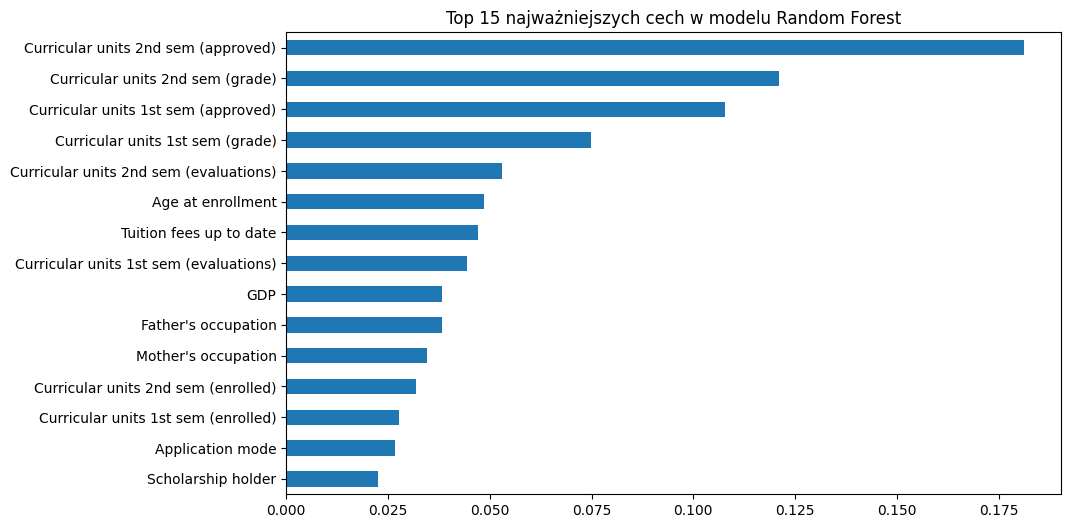

In [34]:
import_cech = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
import_cech = import_cech.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
import_cech.head(15).plot(kind='barh')
plt.title("Top 15 najważniejszych cech w modelu Random Forest")
plt.gca().invert_yaxis()
plt.show()

Dokładność (Accuracy): 77.63%
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       282
           1       0.57      0.37      0.45       165
           2       0.79      0.91      0.84       438

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.78      0.76       885



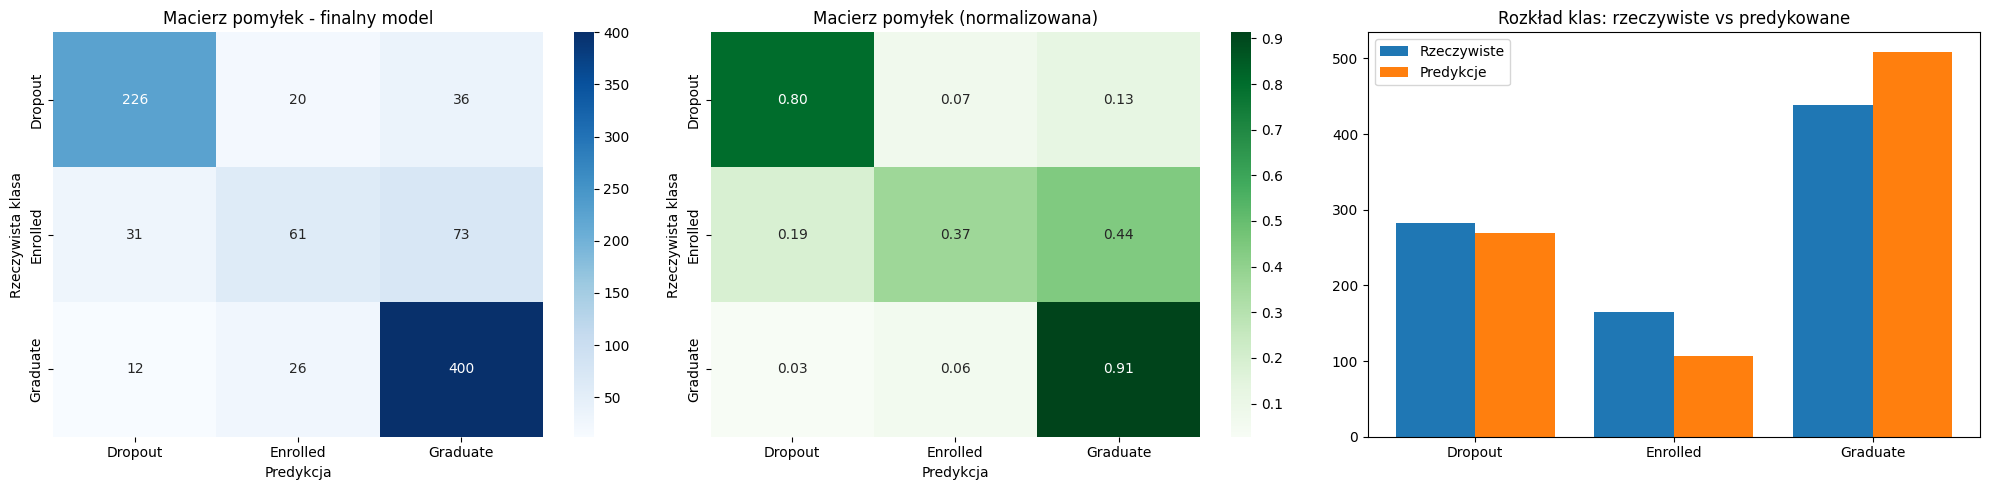

In [35]:
final_model = rf_random.best_estimator_

y_pred_final = final_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print(f"Dokładność (Accuracy): {accuracy_score(y_test, y_pred_final) * 100:.2f}%")
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)
cm_final_norm = confusion_matrix(y_test, y_pred_final, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Macierz pomyłek - finalny model")
axes[0].set_xlabel("Predykcja")
axes[0].set_ylabel("Rzeczywista klasa")

sns.heatmap(cm_final_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Macierz pomyłek (normalizowana)")
axes[1].set_xlabel("Predykcja")
axes[1].set_ylabel("Rzeczywista klasa")

actual_counts = y_test.value_counts().sort_index()
pred_counts_final = pd.Series(y_pred_final).value_counts().sort_index()

x = range(len(labels))
axes[2].bar([i - 0.2 for i in x], actual_counts.values, width=0.4, label="Rzeczywiste")
axes[2].bar([i + 0.2 for i in x], pred_counts_final.reindex(actual_counts.index, fill_value=0).values,
            width=0.4, label="Predykcje")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(labels)
axes[2].set_title("Rozkład klas: rzeczywiste vs predykowane")
axes[2].legend()

plt.tight_layout()
plt.show()

Dokładność (Accuracy): 89.15%
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       282
           1       0.91      0.93      0.92       603

    accuracy                           0.89       885
   macro avg       0.88      0.87      0.87       885
weighted avg       0.89      0.89      0.89       885



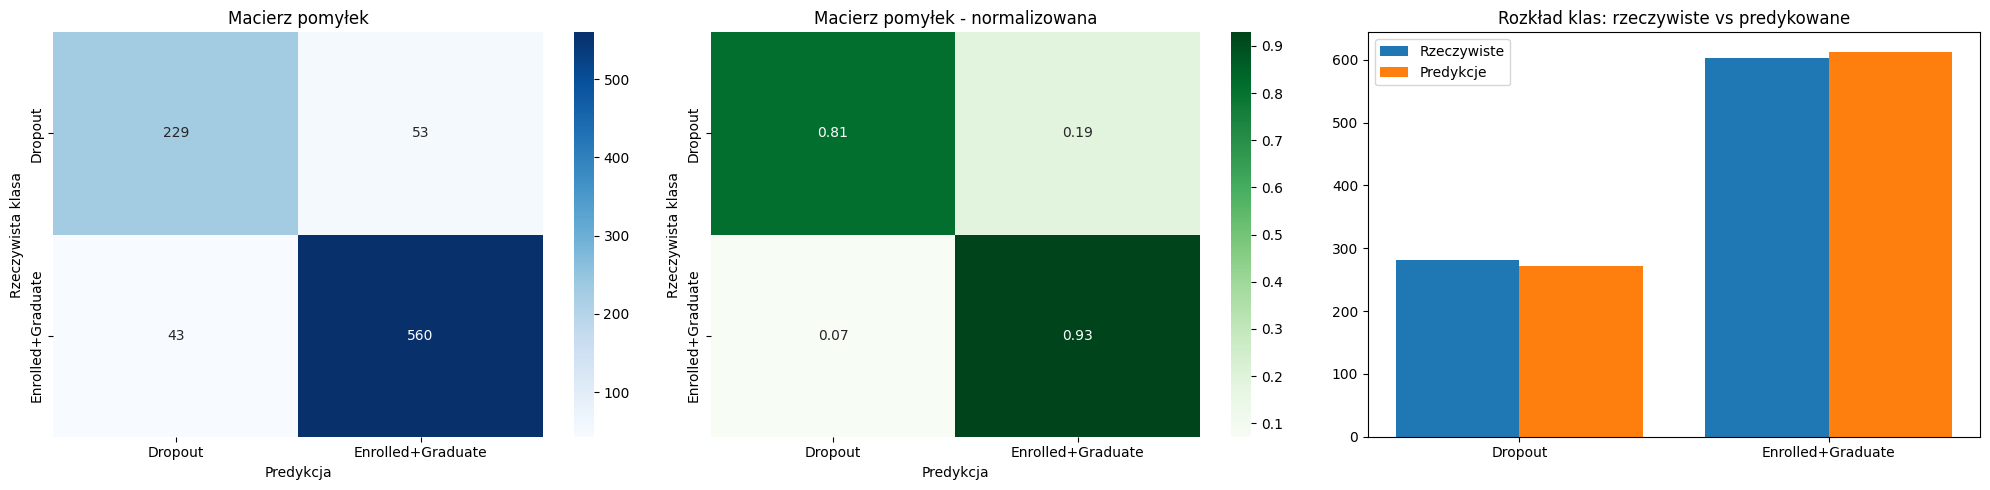

In [48]:
binary_data = data.copy()

mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2, 0: 0, 1: 1, 2: 2}
binary_data['Target'] = binary_data['Target'].replace(mapping)
binary_data['Target'] = pd.to_numeric(binary_data['Target'], errors='coerce')
binary_data['Target'] = binary_data['Target'].replace(2, 1)

nan_count = int(binary_data['Target'].isnull().sum())

if nan_count > 0:
    binary_data = binary_data.dropna(subset=['Target']).reset_index(drop=True)

X_bin = binary_data.drop('Target', axis=1)
y_bin = binary_data['Target'].astype(int)

unique_classes = sorted(list(y_bin.unique()))

if len(unique_classes) < 2:
    raise ValueError("Brak wystarczającej liczby klas w danych binarnych")

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=67
)

rf_bin = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = rf_bin.predict(X_test_bin)

print(f"Dokładność (Accuracy): {accuracy_score(y_test_bin, y_pred_bin) * 100:.2f}%")
print(classification_report(y_test_bin, y_pred_bin))

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
cm_bin_norm = confusion_matrix(y_test_bin, y_pred_bin, normalize='true')

bin_labels = ['Dropout', 'Enrolled+Graduate']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(
    cm_bin,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=bin_labels,
    yticklabels=bin_labels,
    ax=axes[0]
)
axes[0].set_title('Macierz pomyłek')
axes[0].set_xlabel('Predykcja')
axes[0].set_ylabel('Rzeczywista klasa')

sns.heatmap(
    cm_bin_norm,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    xticklabels=bin_labels,
    yticklabels=bin_labels,
    ax=axes[1]
)
axes[1].set_title('Macierz pomyłek - normalizowana')
axes[1].set_xlabel('Predykcja')
axes[1].set_ylabel('Rzeczywista klasa')

actual_counts_bin = y_test_bin.value_counts().sort_index()
pred_counts_bin = pd.Series(y_pred_bin).value_counts().sort_index()

x_pos = range(len(bin_labels))
axes[2].bar(
    [i - 0.2 for i in x_pos],
    actual_counts_bin.values,
    width=0.4,
    label='Rzeczywiste'
)
axes[2].bar(
    [i + 0.2 for i in x_pos],
    pred_counts_bin.reindex(actual_counts_bin.index, fill_value=0).values,
    width=0.4,
    label='Predykcje'
)
axes[2].set_xticks(list(x_pos))
axes[2].set_xticklabels(bin_labels)
axes[2].set_title('Rozkład klas: rzeczywiste vs predykowane')
axes[2].legend()

plt.tight_layout()
plt.show()

### Wnioski z wyników

- **Najlepszy wynik osiągnął XGBoost**:  
    - Accuracy: **0.7887**
    - Precision: **0.7511**
    - Recall: **0.7065**
    - F1-score: **0.7182**

- **Ostateczny Random Forest po optymalizacji** uzyskał nieco słabsze wyniki:  
    - Accuracy: **0.7763**
    - Precision: **0.7320**
    - Recall: **0.6948**
    - F1-score: **0.7045**

- Oznacza to, że **XGBoost był lepszy** od zoptymalizowanego Random Forest we wszystkich metrykach, choć różnice nie były duże.

- Optymalizacja Random Forest przyniosła niewielką poprawę, co sugeruje, że model był już wcześniej blisko swojego praktycznego maksimum dla tego zbioru cech.

- Najtrudniejszą klasą pozostaje Enrolled, ponieważ jest ona pośrednia i częściowo nakłada się znaczeniowo na pozostałe klasy. Model często myli ją z Graduate.

---

### Porównanie rozkładu klas: `[D, E, G]` vs `[D, E+G]`

#### 1. Problem trójklasowy: `Dropout / Enrolled / Graduate`
- Rozkład predykcji dla modeli był podobny:
    - **Dropout**: ok. 266–269
    - **Enrolled**: ok. 104–107
    - **Graduate**: ok. 509–515

- Widać, że model:
    - zaniża liczbę predykcji klasy Enrolled,
    - często przypisuje próbki do Graduate,
    - dość dobrze rozróżnia Dropout.

- To potwierdza, że **Enrolled jest klasą najbardziej niejednoznaczną**.

#### 2. Problem binarny: `Dropout / Enrolled+Graduate`
- Po połączeniu klas Enrolled i Graduate rozkład predykcji stał się:
    - **Dropout**: **272**
    - **Enrolled+Graduate**: **613**

- W tym wariancie model wyraźnie częściej wskazuje klasę **„nie-dropout”**, co jest zgodne z charakterem zbioru danych.

#### 3. Interpretacja porównania
- Po złączeniu klas problem staje się łatwiejszy, ponieważ:
    - znika granica między Enrolled i Graduate,
    - model skupia się głównie na rozróżnieniu Dropout vs reszta,
    - wyniki są zwykle bardziej stabilne i praktyczne.

- W wersji trójklasowej model ma więcej błędów, ponieważ musi rozstrzygać między dwiema podobnymi klasami uczących się studentów.

---

### Podsumowanie
- **XGBoost** okazał się najlepszym modelem w wersji trójklasowej.
- Random Forest po optymalizacji poprawił się tylko nieznacznie.
- Po połączeniu klas Enrolled i Graduate zadanie klasyfikacji staje się prostsze, a model łatwiej oddziela studentów, którzy **porzucą studia**, od tych, którzy **pozostaną w systemie**.